# 🔔Spam/Ham klasifikacija poruka
U ovom projektu treniramo više modela mašinskog učenja kako bismo klasifikovali poruke na **spam** i **ham**.

### 📚 Uvoz biblioteka
Potrebne biblioteke za rad sa podacima (pandas), vizuelizaciju (matplotlib, seaborn) i modele mašinskog učenja (scikit-learn).


In [10]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

### 🔃Učitavanje podataka
Čitamo CSV fajl sa porukama i prikazujemo prvih nekoliko redova.


In [11]:
df = pd.read_csv("messages.csv")
df.head()

,category,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### 🧹Čišćenje podataka
Brišemo prazne vrednosti (ako postoje).


In [12]:
df = df.dropna()
df.isna().sum()

category    0
message     0
dtype: int64

### 👀Pregled i priprema kategorija
Proveravamo raspodelu klasa. Zamenjujemo oznaku **not spam** sa **ham** radi konzistentnosti.


In [13]:
print(df["category"].value_counts())

mapping = {'not spam': 'ham'}
df['category'] = df['category'].astype(object).replace(mapping).astype("category")
df["category"].value_counts()

category
ham         4449
spam         722
not spam     233
Name: count, dtype: int64


category
ham     4682
spam     722
Name: count, dtype: int64

### 🪓 Podela podataka
Delimo podatke na trening i test skup (80% : 20%).


In [14]:
X = df["message"]
y = df["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### 🔢Vektorizacija teksta
Pretvaramo tekstualne poruke u numeričke vektore pomoću TF-IDF tehnike.


In [15]:
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

### 🤔 Definisanje modela
Pripremamo više algoritama za poređenje: Logistic Regression, Naive Bayes, Decision Tree i Support Vector Machine.

In [16]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "Support Vector Machine": LinearSVC()
}

### 🏋️‍♂️ Treniranje i evaluacija
Treniramo svaki model i prikazujemo klasifikacioni izveštaj (preciznost, odziv, F1-score).

In [17]:
for name, model in models.items():
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    print(f"\n{name} - Classification Report:")
    print(classification_report(y_test, y_pred))


Logistic Regression - Classification Report:
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       937
        spam       0.98      0.81      0.89       144

    accuracy                           0.97      1081
   macro avg       0.98      0.90      0.93      1081
weighted avg       0.97      0.97      0.97      1081


Naive Bayes - Classification Report:
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       937
        spam       1.00      0.70      0.82       144

    accuracy                           0.96      1081
   macro avg       0.98      0.85      0.90      1081
weighted avg       0.96      0.96      0.96      1081


Decision Tree - Classification Report:
              precision    recall  f1-score   support

         ham       0.98      0.99      0.98       937
        spam       0.91      0.85      0.88       144

    accuracy                           0.97      1081
   m

### 😵 Vizualizacije matriksa
Prikazujemo matrice konfuzije za svaki model radi vizuelnog poređenja performansi.

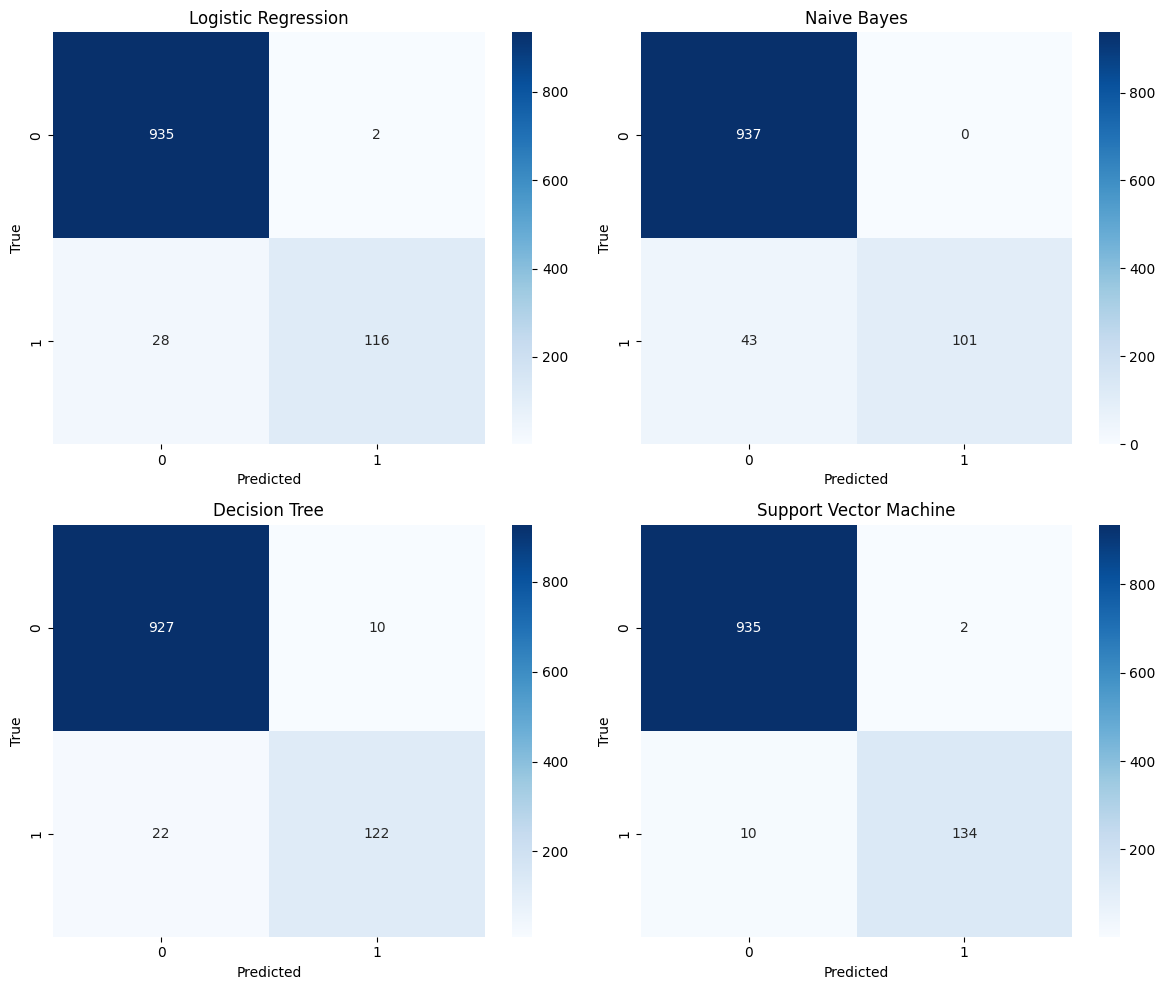

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i])
    axes[i].set_title(name)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("True")

plt.tight_layout()
plt.show()

## 🪞 Refleksija
U ovom zadatku isprobali smo četiri različita modela za klasifikaciju poruka. Svi modeli daju veoma dobre rezultate, ali se razlikuju u preciznosti i odzivu, naročito kod prepoznavanja spam poruka.

- Logistička regresija i SVM pokazali su se kao najtačniji, posebno kod spam poruka, što je ključno jer je prepoznavanje spama teži deo zadatka.

- Naive Bayes je takođe dao solidne rezultate, ali ima slabiji recall za spam (mnogo spama propusti).

- Decision Tree je uravnotežen, ali ipak malo slabiji od SVM-a i logističke regresije u pogledu F1 rezultata za spam.

### Zaključak: Support Vector Machine je najpouzdaniji model u ovom slučaju, jer ima najveću ukupnu tačnost (99%) i najbolji balans između preciznosti i odziva.